In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])
            .size()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [48]:
df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260907_115807_ejection_results.txt', header=None)

In [49]:
df.columns=['mass','time','result']

In [50]:
ejection_df, capture_df=compute_cumulative_outcome_fractions(df, df.mass.unique(),[800,800,800,800,800,800])

In [ ]:
ejection_df.index

In [51]:
ejection_df

,0.000000e+00,9.980039e+02,9.996442e+02,1.999288e+03,1.083848e+04,1.182380e+04,1.280911e+04,1.379443e+04,1.477975e+04,1.492929e+04,...,2.051692e+06,2.081687e+06,2.094686e+06,2.126681e+06,2.132680e+06,2.186672e+06,2.207669e+06,2.218667e+06,2.265660e+06,2.347648e+06
0.030027,0.0,0.0,0.0,0.0,0.00375,0.035,0.06625,0.1075,0.1475,0.1475,...,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500,0.86500
0.009496,0.0,0.0,0.0,0.0,0.00000,0.000,0.00000,0.0000,0.0000,0.0025,...,0.79500,0.79500,0.79500,0.79500,0.79500,0.79500,0.79500,0.79500,0.79500,0.79500
0.004004,0.0,0.0,0.0,0.0,0.00000,0.000,0.00000,0.0000,0.0000,0.0000,...,0.81500,0.81500,0.81500,0.81500,0.81500,0.81500,0.81500,0.81500,0.81500,0.81500
0.001689,0.0,0.0,0.0,0.0,0.00000,0.000,0.00000,0.0000,0.0000,0.0000,...,0.88375,0.88375,0.88375,0.88375,0.88375,0.88375,0.88375,0.88375,0.88375,0.88375
0.000712,0.0,0.0,0.0,0.0,0.00000,0.000,0.00000,0.0000,0.0000,0.0000,...,0.87375,0.87375,0.87375,0.87375,0.87375,0.87375,0.87375,0.87375,0.87375,0.87375
0.000300,0.0,0.0,0.0,0.0,0.00000,0.000,0.00000,0.0000,0.0000,0.0000,...,0.86500,0.86750,0.86875,0.87000,0.87125,0.87250,0.87375,0.87500,0.87625,0.87750


In [61]:
capture_df

,0.000000e+00,9.980039e+02,9.996442e+02,1.999288e+03,1.083848e+04,1.182380e+04,1.280911e+04,1.379443e+04,1.477975e+04,1.492929e+04,...,2.051692e+06,2.081687e+06,2.094686e+06,2.126681e+06,2.132680e+06,2.186672e+06,2.207669e+06,2.218667e+06,2.265660e+06,2.347648e+06
0.030027,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,...,0.01875,0.01875,0.01875,0.01875,0.01875,0.01875,0.01875,0.01875,0.01875,0.01875
0.009496,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,...,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375,0.01375
0.004004,0.00625,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,...,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750
0.001689,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,...,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875
0.000712,0.00125,0.00125,0.00250,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,...,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375
0.000300,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625


(0.0, 300000.0)

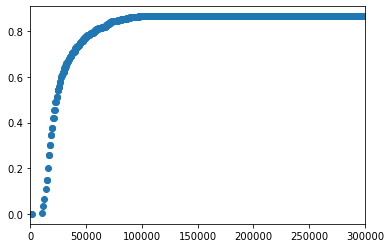

In [58]:
plt.scatter(ejection_df.columns,ejection_df.loc[ejection_df.index[0]])
plt.xlim(0,0.3e6)

In [52]:
files=[
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260907_115807_0.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260907_115807_1.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260907_115807_2.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260907_115807_3.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260907_115807_4.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260907_115807_5.csv'
]

In [53]:
df=pd.DataFrame()
for file in files:
    temp_df=pd.read_csv(file)
    df=pd.concat([df,temp_df], ignore_index=True)

In [59]:
left_counts = ejection_df[ejection_df.columns[-1]]*800

unbound_counts = (
    df.groupby("m_planet")["a"]
    .apply(lambda x: (x == "Unbound").sum())
)

total_affected = left_counts.add(unbound_counts, fill_value=0)

In [60]:
total_affected

0.000300    704.0
0.000712    706.0
0.001689    734.0
0.004004    730.0
0.009496    759.0
0.030027    728.0
dtype: float64

In [12]:
def log_fit(q, a, b):
    return a * np.log10(q) + b

In [13]:
def e_frac_vs_mass(q):
    a=0.08509622694638502
    b=1.0913245932397357
    return a * np.log10(q) + b
def imf(Mstar):
    """Salpeter IMF, arbitrary normalization."""
    
    return 1000*Mstar**(-2.35)
def available_mass(M_star):
    """Moro_Martin 2018 Section 3.2.1"""
    return 1e-4*M_star

In [14]:
def integrated_ejection_mass(masses, e_frac=e_frac_vs_mass, imf=imf, planet_mass=0.000954588):
    weights=imf(masses)
    fractions=e_frac(planet_mass/masses)
    disc_mass=available_mass(masses)

    average_ejected_mass = np.trapz(weights * fractions * disc_mass, x=masses)/ np.trapz(weights, x=masses)
    return average_ejected_mass

In [15]:
masses = np.logspace(
    np.log10(0.08),
    np.log10(100),
    10000)

In [16]:
stellar_densities = np.array([
    0.08,
    6.0,
    326
])

# Planet masses [M_sun]
planet_masses = np.array([
    3.003e-6,      # Earth
    9.54588e-4,    # Jupiter
])

# Labels for table
planet_labels = [
    r"1 M_Earth",
    r"1 M_Jupiter"
]

table = pd.DataFrame(
    index=stellar_densities,
    columns=planet_labels,
    dtype=float
)

for density in stellar_densities:
    for planet_mass, label in zip(planet_masses, planet_labels):

        mass_per_star = integrated_ejection_mass(
            masses,
            planet_mass=planet_mass
        )

        table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"

table.index.name = "Stellar Density [stars / pc^3]"

table

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_49175/3147123783.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4774' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"
/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_49175/3147123783.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6380' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"


,1 M_Earth,1 M_Jupiter
Stellar Density [stars / pc^3],,
0.08,0.4774,0.6380
6.00,35.8041,47.8517
326.00,1945.3574,2599.9447


In [22]:
def a_distribution(a, C=350,beta=-0.86,a_0=3.6, gamma=1.59):
    prefactor=C*a**beta
    term_2=(1-np.exp(-(a/a_0)**gamma))
    return prefactor*term_2
def surface_density(a, r=-1):
    return a**r

    

In [24]:
def fulton_a(a, beta = -0.86,a0 = 3.6,gamma = 1.58):

    return (
        a**beta
        * (1 - np.exp(-(a / a0)**gamma))
    )
def log_normalized_fulton_a(
    beta=-0.86,
    a0=3.6,
    gamma=1.58,
    a_min=np.log10(0.03),
    a_max=np.log10(30)
):
    a = np.logspace(a_min, a_max, 1000)
    log_a = np.log10(a)

    fa = fulton_a(a)

    p_a = fa / np.trapz(fa, x=log_a)

    return a, p_a

In [30]:
a, p_a = log_normalized_fulton_a()

np.trapz(p_a, x=np.log10(a))

1.0

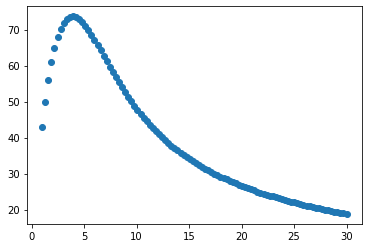

In [21]:
x=np.linspace(1,30,100)
y=a_distribution(x)
plt.scatter(x,y)

In [35]:
def chaotic_zone_mass_fraction(
    Mstar,
    a_planet,
    planet_mass,
    surface_density=surface_density,
    r_disc_min=0.03,
    r_disc_max=30,
    n=1000,
):
    q = planet_mass / Mstar

    delta_a = 1.3 * q**(2/7) * a_planet

    cz_min = max(a_planet - delta_a, r_disc_min)
    cz_max = min(a_planet + delta_a, r_disc_max)

    # No overlap between chaotic zone and disk
    if cz_max <= cz_min:
        return 0.0

    # Mass in chaotic zone
    r_cz = np.linspace(cz_min, cz_max, n)
    sigma_cz = surface_density(r_cz, Mstar)

    M_cz = np.trapz(
        2 * np.pi * r_cz * sigma_cz,
        x=r_cz
    )

    # Total disk mass represented by surface-density model
    r_disc = np.linspace(r_disc_min, r_disc_max, n)
    sigma_disc = surface_density(r_disc, Mstar)

    M_disc = np.trapz(
        2 * np.pi * r_disc * sigma_disc,
        x=r_disc
    )

    return M_cz / M_disc

In [38]:
def average_chaotic_zone_fraction(m_star, planet_mass):
    a, p_a = log_normalized_fulton_a()

    cz_fractions = np.array([
        chaotic_zone_mass_fraction(
            Mstar=m_star,
            a_planet=a_planet,
            planet_mass=planet_mass
        )
        for a_planet in a
    ])

    average_fraction = np.trapz(
        p_a * cz_fractions,
        x=np.log10(a)
    )

    return average_fraction

In [39]:
average_chaotic_zone_fraction(1, 0.001)

0.03613957418082916